## Exercise 7.1

In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [2]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [3]:
# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


We visualize some examples.

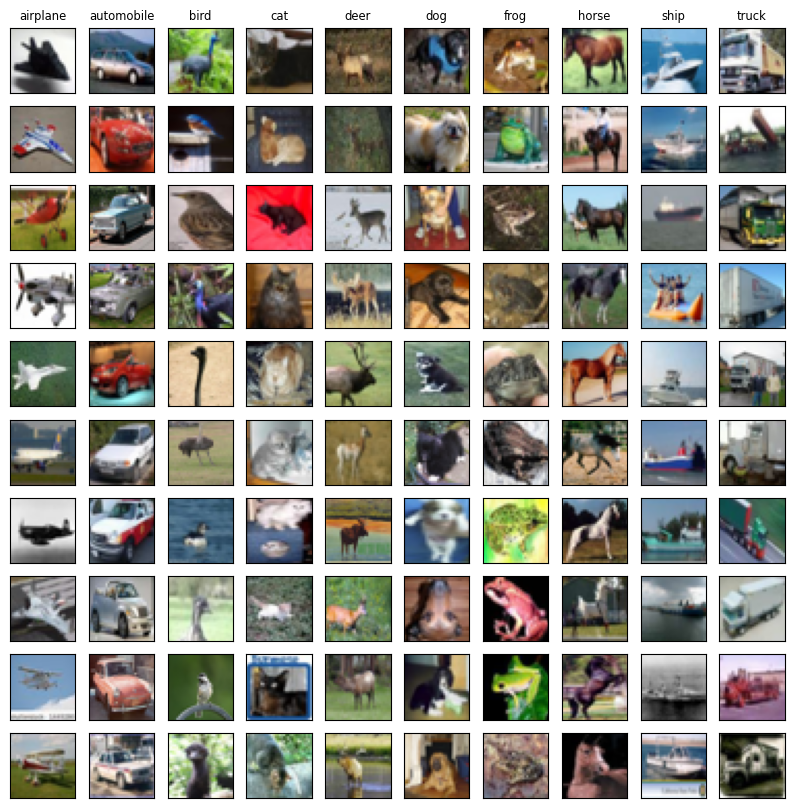

In [4]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train);

In the following block, we separate some of the test data for validation, we apply one-hot encoding for the labels, and we normalize the integer RGB values to the range (0,1).

In [5]:
# Hint: use 20% of the test data for validation
print(x_test.shape)
x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)

# Hint: normalize the data
x_train_norm = np.float32(x_train) / 255
x_valid_norm = np.float32(x_valid) / 255
x_test_norm = np.float32(x_test) / 255

(10000, 32, 32, 3)


### Classification with a fully connected network

We first try the classification with a fully connected network

In [6]:
# ----------------------------------------------------------
# Define model
# ----------------------------------------------------------
model = tf.keras.models.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),  # (32,32,3) --> (3072)
        # this time the flatten operation is directly integrated into the network
        # structure so that we can use the same input data later for a convolutional neural network.
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dense(10),
        # softmax activation to transform output into probabilities
        layers.Activation('softmax'),
    ],
    name="nn",
)

print(model.summary())

E0000 00:00:1780906634.787921    7944 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,050 (3.26 MB)

 Trainable params: 855,050 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

None


We train the model monitoring the loss and the accuracy on the train and validation datasets.

In [12]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

model.fit(
    x_train_norm, y_train_onehot,

    batch_size=32,
    epochs=25, # train at least for 20 epochs
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[CalculateMetrics(), 
               tf.keras.callbacks.CSVLogger("checkpoints/ex7.1/history_{}.csv".format(model.name))],
);

Epoch 1/25
1563/1563 - 9s - 6ms/step - accuracy: 0.4338 - loss: 1.5656 - val_accuracy: 0.4455 - val_loss: 1.5448 - train_loss: 1.4801 - train_acc: 0.4765
Epoch 2/25
1563/1563 - 8s - 5ms/step - accuracy: 0.4347 - loss: 1.5604 - val_accuracy: 0.4635 - val_loss: 1.4990 - train_loss: 1.4346 - train_acc: 0.4956
Epoch 3/25
1563/1563 - 9s - 6ms/step - accuracy: 0.4389 - loss: 1.5534 - val_accuracy: 0.4400 - val_loss: 1.5653 - train_loss: 1.4791 - train_acc: 0.4765
Epoch 4/25
1563/1563 - 9s - 6ms/step - accuracy: 0.4350 - loss: 1.5579 - val_accuracy: 0.4515 - val_loss: 1.5202 - train_loss: 1.4346 - train_acc: 0.4930
Epoch 5/25
1563/1563 - 9s - 6ms/step - accuracy: 0.4383 - loss: 1.5516 - val_accuracy: 0.4430 - val_loss: 1.5265 - train_loss: 1.4387 - train_acc: 0.4926
Epoch 6/25
1563/1563 - 9s - 5ms/step - accuracy: 0.4384 - loss: 1.5522 - val_accuracy: 0.4255 - val_loss: 1.5606 - train_loss: 1.4903 - train_acc: 0.4759
Epoch 7/25
1563/1563 - 8s - 5ms/step - accuracy: 0.4458 - loss: 1.5402 - val

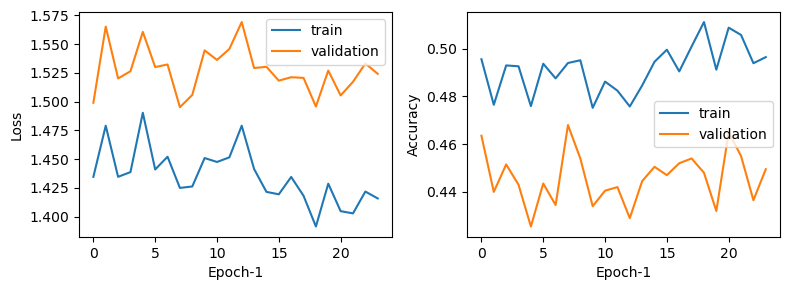

In [14]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("checkpoints/ex7.1/history_{}.csv".format(model.name), delimiter=",", names=True)
train_acc = history["train_acc"][1:]
val_acc = history["val_accuracy"][1:]
train_loss = history["train_loss"][1:]
val_loss = history["val_loss"][1:]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(train_loss,label="train")
plt.plot(val_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

As usual, the loss on the validation set is slightly higher due to the generalization error. This is also seen as a lower accuracy with respect to the train set.

In [16]:
# evaluate performance
print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |    Loss |   Accuracy |   Test error rate [%] |
|------------+---------+------------+-----------------------|
| Train      | 1.41584 |   0.49644  |               50.356  |
| Validation | 1.52423 |   0.4495   |               55.05   |
| Test       | 1.50868 |   0.454125 |               54.5875 |


The accuracy achieved on the test dataset is around 45%. Of course, this is much better than a random guess (which would have an accuracy of 10%), but there is room for improvement. We can plot the confusion matrix to better visualize the performance.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


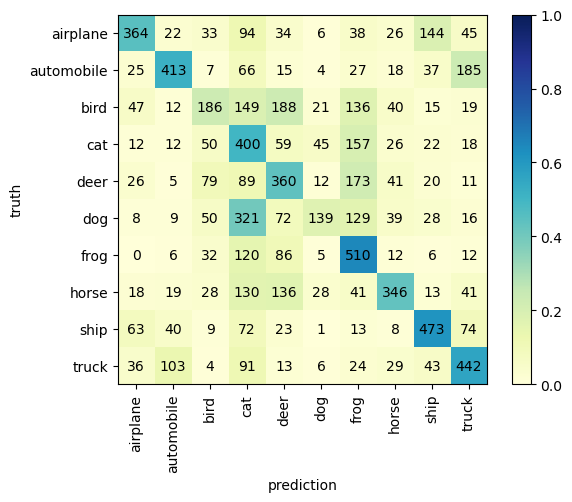

In [17]:
# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

Despite the stack in the diagonal, there are clear problems on some classes. For example, the model tends to classify as cats or frogs. We can plot some examples of correctly and incorrectly classified images.

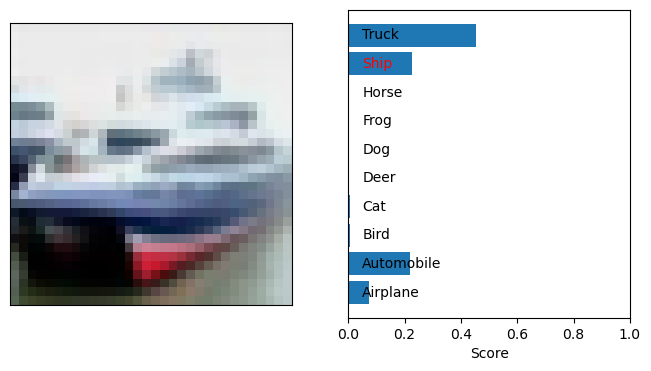

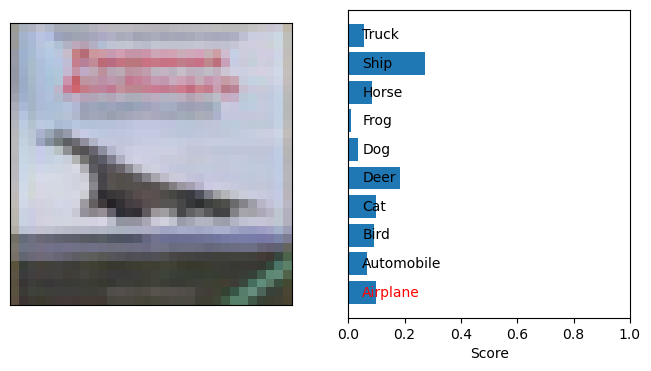

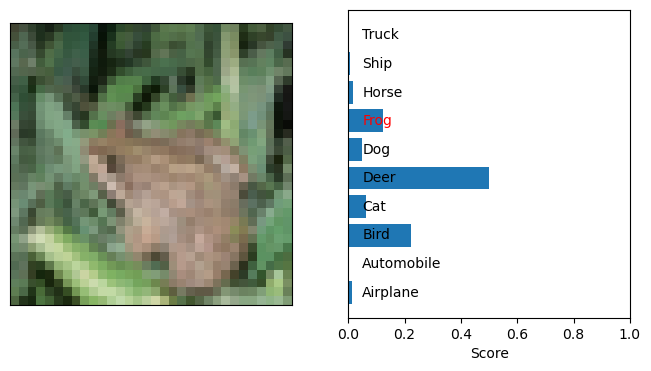

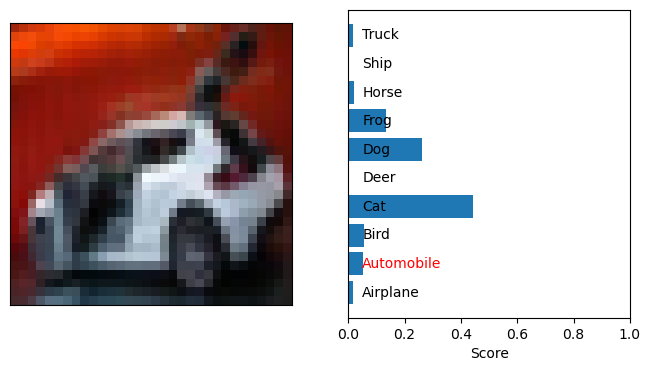

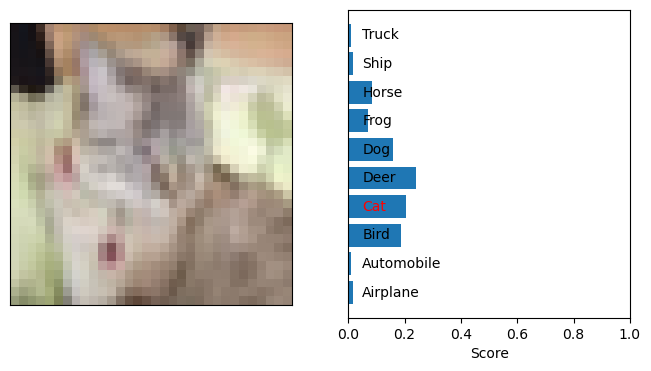

In [ ]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 5 false classifications
for i in i0[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

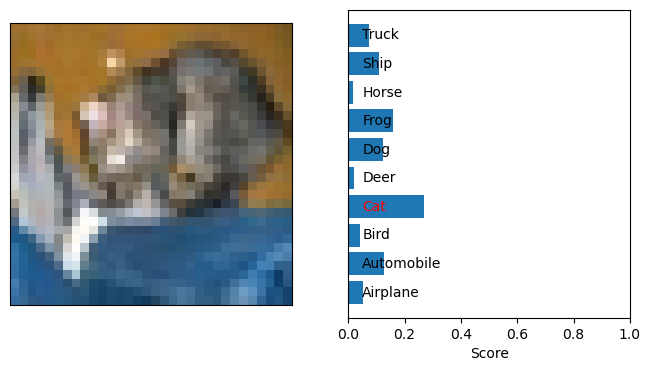

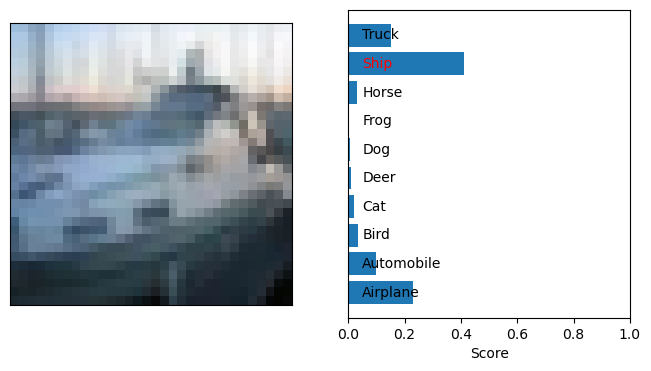

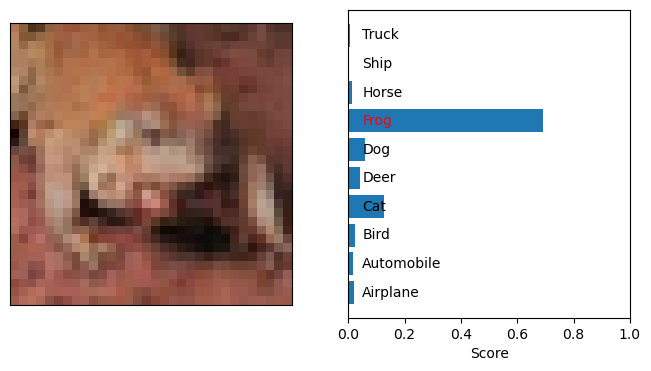

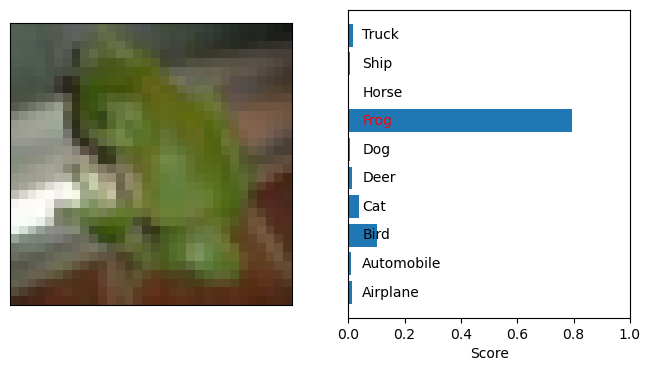

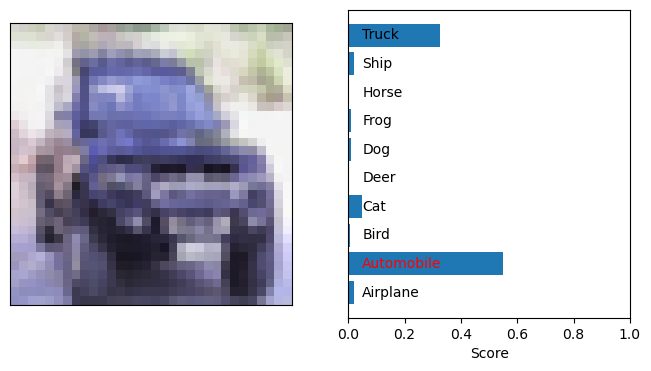

In [ ]:
# plot first 5 correct classifications
for i in i1[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

### Classification with a CNN
In order to improve the results, we will use a convolutional neural network to classify the images.

In [20]:
# Hint: this code snipped shows how to define convolution and maxpooling layers. For more information see
# https://keras.io/api/layers/convolution_layers/convolution2d/
# https://keras.io/api/layers/pooling_layers/max_pooling2d/
model = tf.keras.models.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, kernel_size=(3, 3), padding="valid", activation="relu"),
        layers.MaxPooling2D((2,2), strides=(2,2)),
        layers.Conv2D(32, kernel_size=(3, 3), padding="valid", activation="relu"),
        layers.MaxPooling2D((2,2), strides=(2,2)),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ],
    name="cnn",
)

print(model.summary())

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

model.fit(
    x_train_norm, y_train_onehot,

    batch_size=32,
    epochs=40,
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[CalculateMetrics(), 
               tf.keras.callbacks.CSVLogger("checkpoints/ex7.1/history_{}.csv".format(model.name))],
);

Epoch 1/40
1563/1563 - 11s - 7ms/step - accuracy: 0.7325 - loss: 0.7673 - val_accuracy: 0.7040 - val_loss: 0.8915 - train_loss: 0.6610 - train_acc: 0.7771
Epoch 2/40
1563/1563 - 10s - 6ms/step - accuracy: 0.7328 - loss: 0.7672 - val_accuracy: 0.7065 - val_loss: 0.8894 - train_loss: 0.6567 - train_acc: 0.7719
Epoch 3/40
1563/1563 - 10s - 6ms/step - accuracy: 0.7342 - loss: 0.7634 - val_accuracy: 0.7000 - val_loss: 0.9244 - train_loss: 0.6822 - train_acc: 0.7631
Epoch 4/40
1563/1563 - 10s - 6ms/step - accuracy: 0.7369 - loss: 0.7587 - val_accuracy: 0.6940 - val_loss: 0.9346 - train_loss: 0.6885 - train_acc: 0.7594
Epoch 5/40
1563/1563 - 10s - 6ms/step - accuracy: 0.7361 - loss: 0.7605 - val_accuracy: 0.6930 - val_loss: 0.9067 - train_loss: 0.6693 - train_acc: 0.7720
Epoch 6/40
1563/1563 - 10s - 6ms/step - accuracy: 0.7365 - loss: 0.7532 - val_accuracy: 0.6935 - val_loss: 0.8979 - train_loss: 0.6479 - train_acc: 0.7811
Epoch 7/40
1563/1563 - 10s - 7ms/step - accuracy: 0.7365 - loss: 0.755

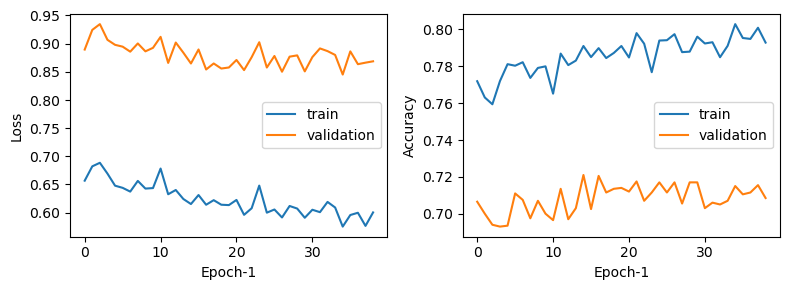

In [24]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("checkpoints/ex7.1/history_{}.csv".format(model.name), delimiter=",", names=True)
train_acc = history["train_acc"][1:]
val_acc = history["val_accuracy"][1:]
train_loss = history["train_loss"][1:]
val_loss = history["val_loss"][1:]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(train_loss,label="train")
plt.plot(val_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

We again observe some generalization error, which is a bit larger in this case. We have some overfitting.

In [25]:
# evaluate performance
print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |     Loss |   Accuracy |   Test error rate [%] |
|------------+----------+------------+-----------------------|
| Train      | 0.600396 |   0.79282  |               20.718  |
| Validation | 0.868601 |   0.7085   |               29.15   |
| Test       | 0.859321 |   0.707875 |               29.2125 |


With the CNN, the accuracy achieved on the test dataset is around 70%. It is certainly a great upgrade. Of course, it could be improved with more complex architectures. But it seems quite good seeing the simplicity of the model and the quality of the images (some of them are difficult to distinguish even for a human).

We can plot the confusion matrix to better visualize the performance.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


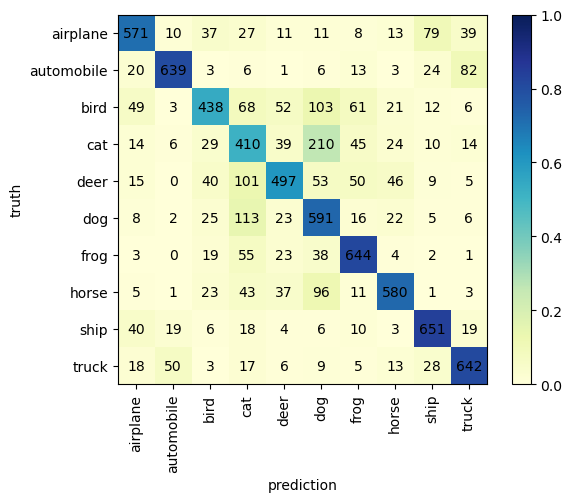

In [26]:
# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

The stack in the diagonal is now very strong. The main problems come from the misclassification of birds, cats and deers. For example, cats are often mistaken for dogs by the model.

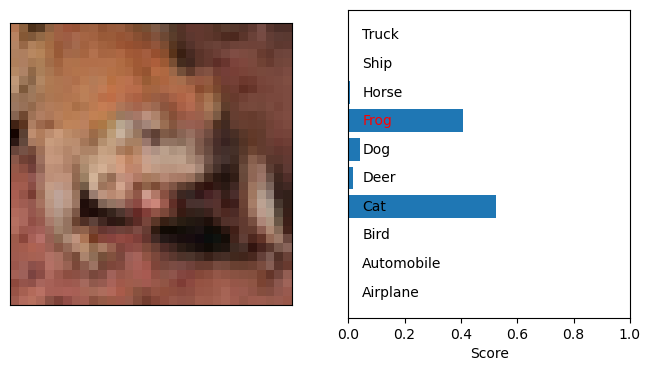

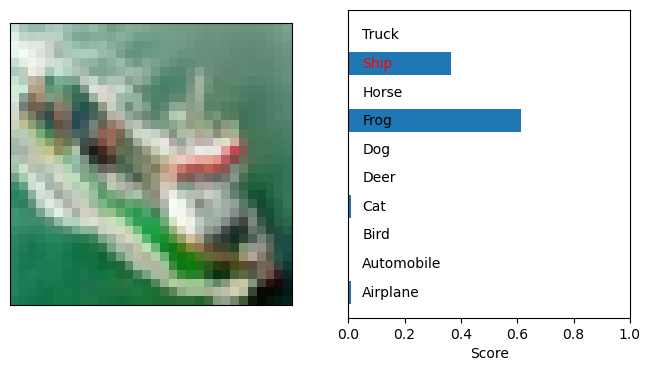

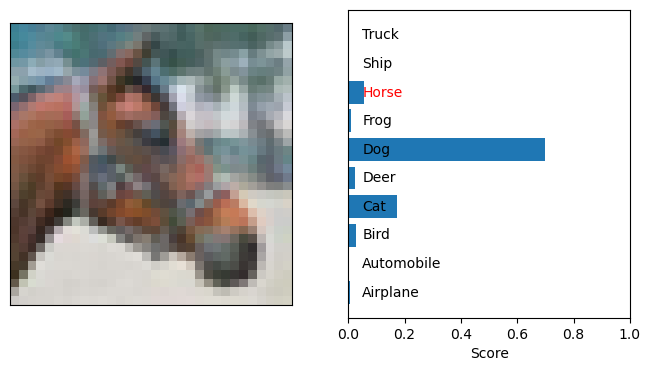

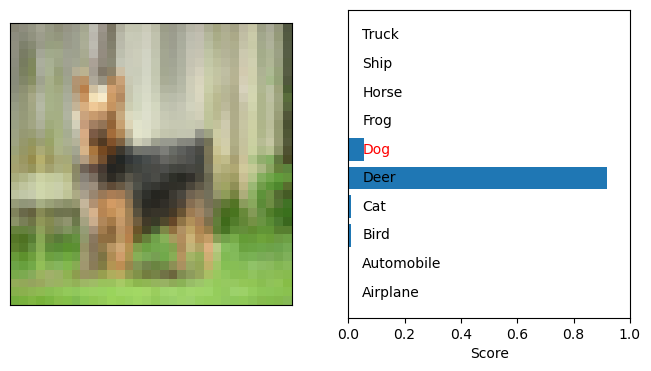

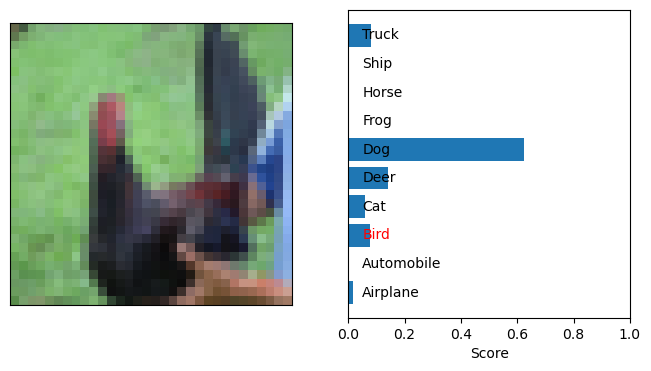

In [ ]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 5 false classifications
for i in i0[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

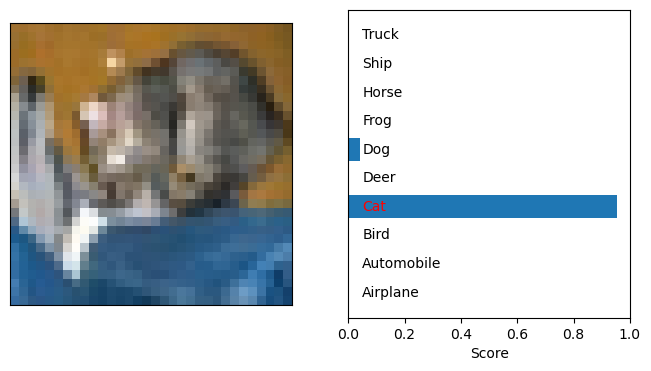

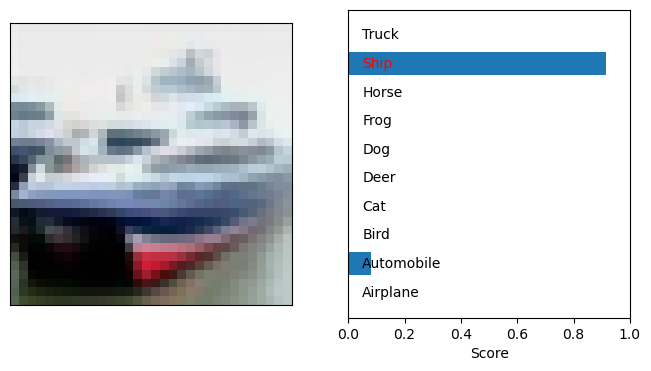

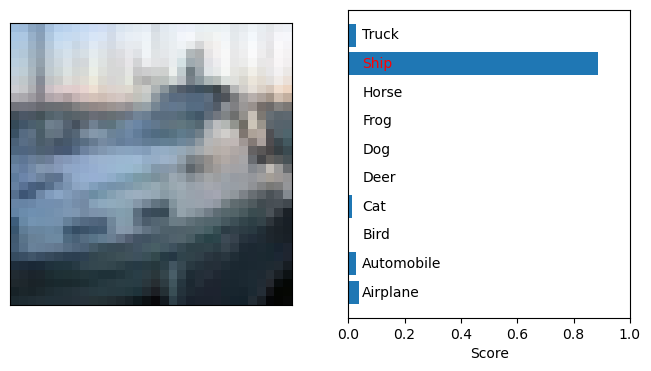

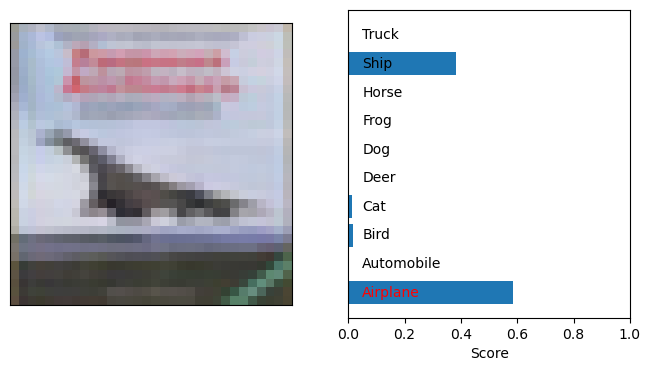

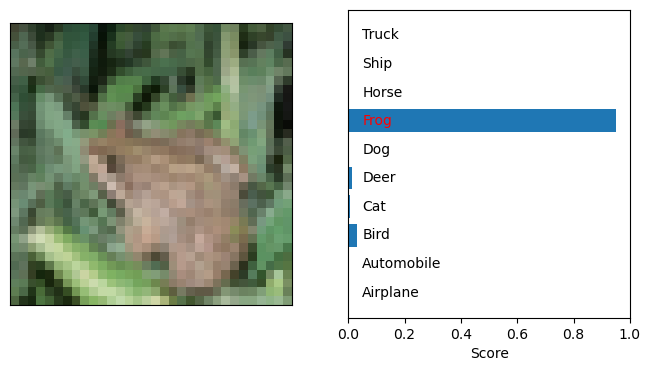

In [29]:
# plot first 5 correct classifications
for i in i1[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

Compared with the fully connected network, in general the CNN is more sure of its decision. There is clearly one class with a large probabilty with respect to the others. If the image is unclear, there is sometimes two.